# Customer Segmentation & Marketing Analysis Using Python

## Problem Statement

The company has customer data covering demographics, spending behavior, purchase channels, and marketing campaign responses, but it is difficult to identify valuable customer groups and understand where marketing efforts can be improved.

## Objective

Analyze customer demographics, spending behavior, purchasing channels, and campaign responses to identify customer segments and generate actionable business recommendations.

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook


## 1. Business Questions

- Who are the highest-value customers?
- Which products generate the most customer spending?
- Which purchase channels are used most?
- Which marketing campaigns receive the strongest response?
- How are income and age related to customer spending?
- Which customer segments should receive different marketing strategies?


In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

sns.set_theme(style="whitegrid")

import os

image_folder = r"C:\Users\mahen\Downloads\customer_project_images"

os.makedirs(image_folder, exist_ok=True)

plt.savefig(
    os.path.join(image_folder, "chart_name.png"),
    dpi=300,
    bbox_inches="tight"
)


<Figure size 640x480 with 0 Axes>

## 2. Load the Data

The original dataset is comma-separated. Using `sep="\t"` would incorrectly load the complete row into one column.


In [2]:
df = pd.read_csv(
    r"C:\Users\mahen\Downloads\marketing_campaign.csv",
    sep=","
)

df.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [4]:
df.shape


(2240, 29)

In [5]:
df.columns.tolist()


['ID',
 'Year_Birth',
 'Education',
 'Marital_Status',
 'Income',
 'Kidhome',
 'Teenhome',
 'Dt_Customer',
 'Recency',
 'MntWines',
 'MntFruits',
 'MntMeatProducts',
 'MntFishProducts',
 'MntSweetProducts',
 'MntGoldProds',
 'NumDealsPurchases',
 'NumWebPurchases',
 'NumCatalogPurchases',
 'NumStorePurchases',
 'NumWebVisitsMonth',
 'AcceptedCmp3',
 'AcceptedCmp4',
 'AcceptedCmp5',
 'AcceptedCmp1',
 'AcceptedCmp2',
 'Complain',
 'Z_CostContact',
 'Z_Revenue',
 'Response']

## 3. Data Quality Checks


In [6]:
df.isnull().sum()


ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [7]:
df.duplicated().sum()


np.int64(0)

In [8]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,2240.0,NaN,NaN,NaN,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,NaN,NaN,NaN,1968.805804,11.984069,1893.0,1959.0,1970.0,1977.0,1996.0
Education,2240,5,Graduation,1127,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital_Status,2240,8,Married,864,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Income,2216.0,NaN,NaN,NaN,52247.251354,25173.076661,1730.0,35303.0,51381.5,68522.0,666666.0
Kidhome,2240.0,NaN,NaN,NaN,0.444196,0.538398,0.0,0.0,0.0,1.0,2.0
Teenhome,2240.0,NaN,NaN,NaN,0.50625,0.544538,0.0,0.0,0.0,1.0,2.0
Dt_Customer,2240,663,31-08-2012,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Recency,2240.0,NaN,NaN,NaN,49.109375,28.962453,0.0,24.0,49.0,74.0,99.0
MntWines,2240.0,NaN,NaN,NaN,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0


## 4. Data Cleaning & Type Conversion

Income is a numerical field, so it should remain numeric. Customer enrollment dates are converted to datetime for time-based analysis.


In [9]:
df["Income"] = pd.to_numeric(df["Income"], errors="coerce")

df["Dt_Customer"] = pd.to_datetime(
    df["Dt_Customer"],
    dayfirst=True,
    errors="coerce"
)

df[["Income", "Dt_Customer"]].head()


,Income,Dt_Customer
0,58138.0,2012-09-04
1,46344.0,2014-03-08
2,71613.0,2013-08-21
3,26646.0,2014-02-10
4,58293.0,2014-01-19


In [10]:
df[["Income", "Dt_Customer"]].dtypes


Income                float64
Dt_Customer    datetime64[ns]
dtype: object

In [11]:
df.isnull().sum().sort_values(ascending=False).head(10)


Income               24
ID                    0
NumDealsPurchases     0
Z_Revenue             0
Z_CostContact         0
Complain              0
AcceptedCmp2          0
AcceptedCmp1          0
AcceptedCmp5          0
AcceptedCmp4          0
dtype: int64

## 5. Feature Engineering


In [12]:
# Use the latest customer enrollment year as the reference year.
# This keeps the age calculation aligned with the period represented by the dataset.
analysis_year = df["Dt_Customer"].dt.year.max()

df["Age"] = analysis_year - df["Year_Birth"]

# Flag unrealistic ages rather than silently deleting the original records.
df["Age_Valid"] = df["Age"].between(18, 100)

df["Children"] = df["Kidhome"] + df["Teenhome"]

df[["Year_Birth", "Age", "Children"]].head()


,Year_Birth,Age,Children
0,1957,57,0
1,1954,60,2
2,1965,49,0
3,1984,30,1
4,1981,33,1


### Total Spending

Total spending combines spending across all six product categories.


In [13]:
product_cols = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

df["Total_Spending"] = df[product_cols].sum(axis=1)


### Total Purchases

Total purchases combines purchases made through the web, catalog, and store channels.


In [14]:
purchase_cols = [
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases"
]

df["Total_Purchases"] = df[purchase_cols].sum(axis=1)


### Total Campaigns Accepted


In [15]:
campaign_cols = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5"
]

df["Campaigns_Accepted"] = df[campaign_cols].sum(axis=1)


In [16]:
df[[
    "Age",
    "Children",
    "Total_Spending",
    "Total_Purchases",
    "Campaigns_Accepted"
]].head()


,Age,Children,Total_Spending,Total_Purchases,Campaigns_Accepted
0,57,0,1617,22,0
1,60,2,27,4,0
2,49,0,776,20,0
3,30,1,53,6,0
4,33,1,422,14,0


# 6. Exploratory Data Analysis

## EDA 1 — Age Distribution

**Business Question:** What is the age distribution of our customers?


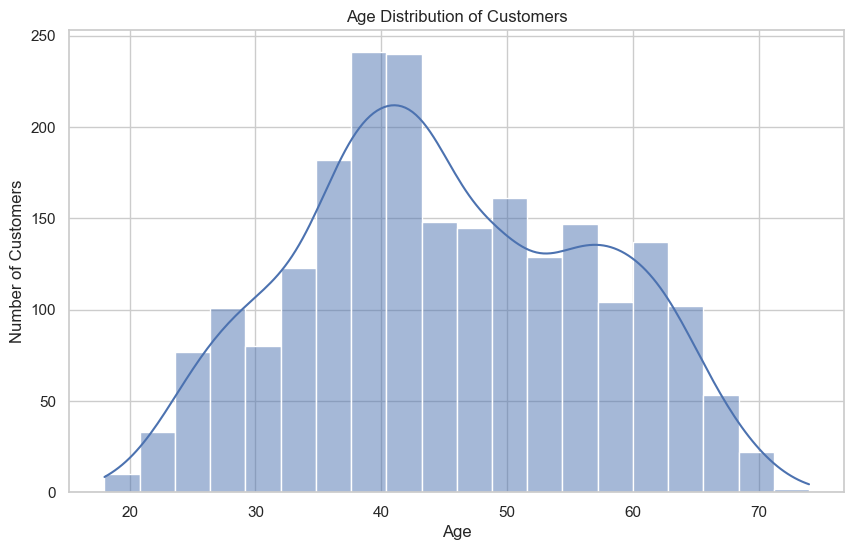

In [46]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df[df["Age_Valid"]],
    x="Age",
    bins=20,
    kde=True
)

plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.savefig(
    os.path.join(image_folder, "01_age_distribution.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()



### Business Insight

The customer base is concentrated in middle and older age groups. Invalid age records are excluded from the age visualization so that unrealistic birth years do not distort the analysis.

**Business opportunity:** Use age as one input for targeted campaigns rather than applying the same offer to every customer.


## EDA 2 — Income Distribution

**Business Question:** What is the income distribution of customers?


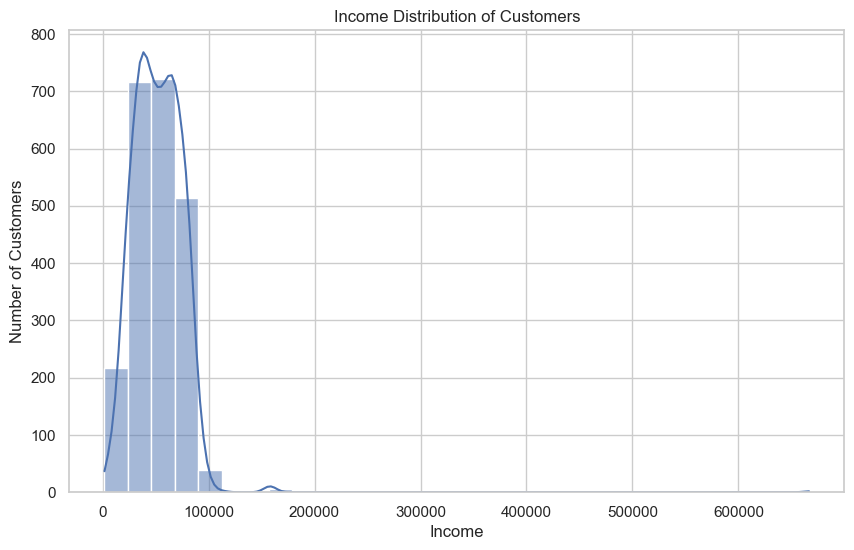

In [47]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Income",
    bins=30,
    kde=True
)

plt.title("Income Distribution of Customers")
plt.xlabel("Income")
plt.ylabel("Number of Customers")


plt.savefig(
    os.path.join(image_folder, "02_income_distribution.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


### Business Insight

Most customers fall within the main income range, while a smaller number of customers have unusually high income values.

**Business opportunity:** Use income as one factor for differentiated offers, while checking extreme values before using averages for decisions.


## EDA 3 — Education Distribution

**Business Question:** How is the customer base distributed across education levels?


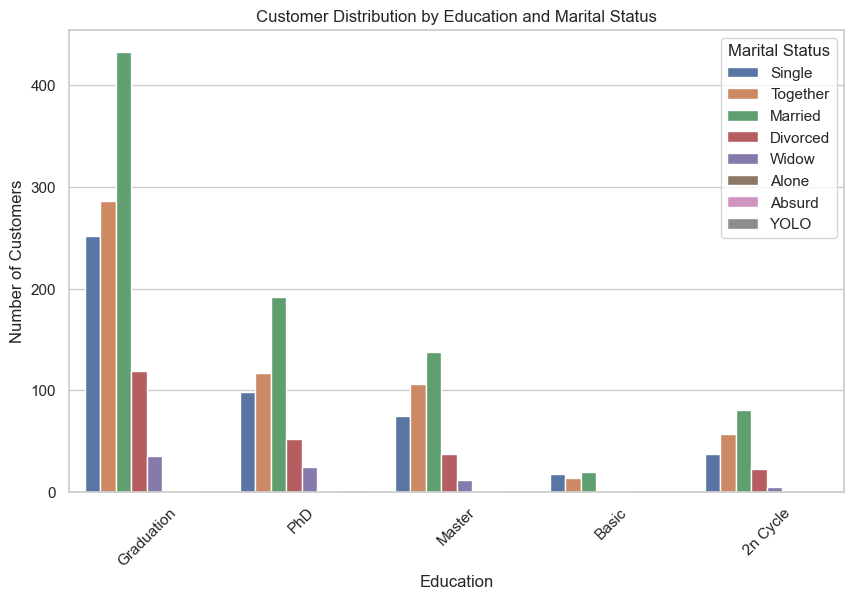

In [48]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Education",
    hue="Marital_Status"
)

plt.title("Customer Distribution by Education and Marital Status")
plt.xlabel("Education")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.legend(title="Marital Status")
plt.savefig(
    os.path.join(image_folder, "03_education_marital_status.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


### Business Insight

Education groups contain different customer profiles when marital status is considered. This supports the use of customer characteristics together rather than relying on a single demographic variable.


## EDA 4 — Marital Status Distribution

**Business Question:** What is the marital status distribution of customers?


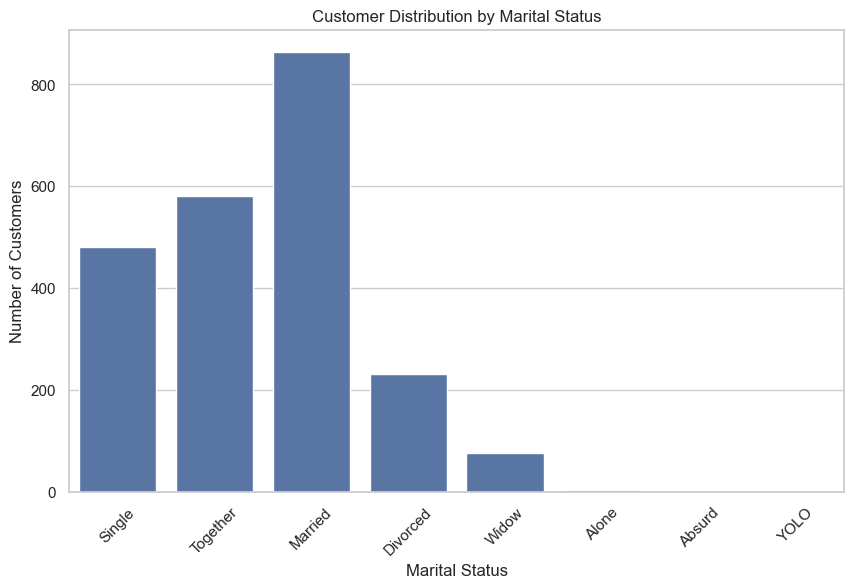

In [49]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Marital_Status"
)

plt.title("Customer Distribution by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.savefig(
    os.path.join(image_folder, "04_marital_status.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


### Business Insight

The customer base contains several marital-status groups, with a few categories representing relatively small customer populations.

**Business opportunity:** Use customer profile information as a supporting variable when designing targeted campaigns.


## EDA 5 — Product Spending Analysis

**Business Question:** Which product categories generate the most customer spending?


In [21]:
product_spending = df[product_cols].sum()

product_spending.index = [
    "Wine",
    "Fruits",
    "Meat",
    "Fish",
    "Sweets",
    "Gold"
]

product_spending


Wine      680816
Fruits     58917
Meat      373968
Fish       84057
Sweets     60621
Gold       98609
dtype: int64

In [22]:
product_share = (
    product_spending
    / product_spending.sum()
    * 100
).sort_values(ascending=False)

product_share


Wine      50.171114
Meat      27.558681
Gold       7.266755
Fish       6.194380
Sweets     4.467320
Fruits     4.341748
dtype: float64

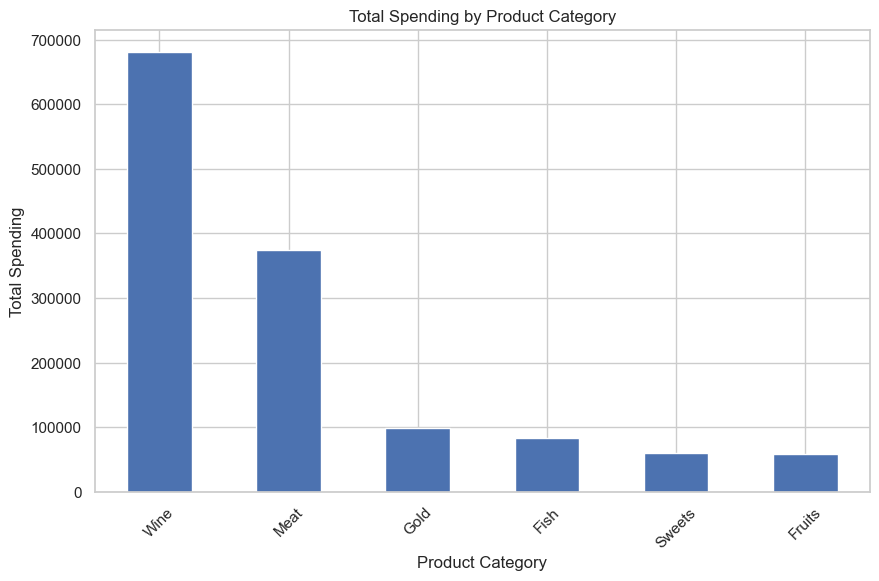

In [50]:
plt.figure(figsize=(10, 6))

product_spending.sort_values(ascending=False).plot(kind="bar")

plt.title("Total Spending by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Spending")
plt.xticks(rotation=45)
plt.savefig(
    os.path.join(image_folder, "05_product_spending.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Business Insight

Wine and Meat products are among the strongest spending categories, while other categories contribute less.

**Recommendation:** Protect the performance of high-spending categories and test cross-sell or bundle offers to increase spending in weaker categories.


## EDA 6 — Purchase Channel Analysis

**Business Question:** Do customers prefer the website, catalog, or physical store?


In [24]:
purchase_channels = df[purchase_cols].sum()

purchase_channels.index = ["Web", "Catalog", "Store"]

purchase_share = (
    purchase_channels
    / purchase_channels.sum()
    * 100
).sort_values(ascending=False)

purchase_share


Store      46.184524
Web        32.581989
Catalog    21.233486
dtype: float64

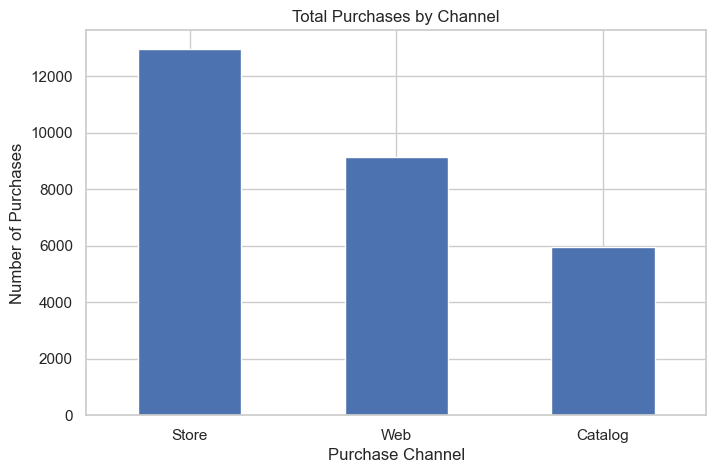

In [51]:
plt.figure(figsize=(8, 5))

purchase_channels.sort_values(ascending=False).plot(kind="bar")

plt.title("Total Purchases by Channel")
plt.xlabel("Purchase Channel")
plt.ylabel("Number of Purchases")
plt.xticks(rotation=0)
plt.savefig(
    os.path.join(image_folder, "06_purchase_channels.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


### Business Insight

Store purchases are the strongest channel, while catalog purchases are comparatively lower.

**Recommendation:** Continue supporting the store channel while testing targeted digital and catalog promotions to improve weaker channels.


## EDA 7 — Marketing Campaign Performance

**Business Question:** Which campaigns generated the most customer responses?


In [26]:
campaign_response = df[campaign_cols + ["Response"]].sum()

campaign_response.index = [
    "Campaign 1",
    "Campaign 2",
    "Campaign 3",
    "Campaign 4",
    "Campaign 5",
    "Latest Campaign"
]

campaign_response = campaign_response.sort_values(ascending=False)

campaign_response


Latest Campaign    334
Campaign 4         167
Campaign 3         163
Campaign 5         163
Campaign 1         144
Campaign 2          30
dtype: int64

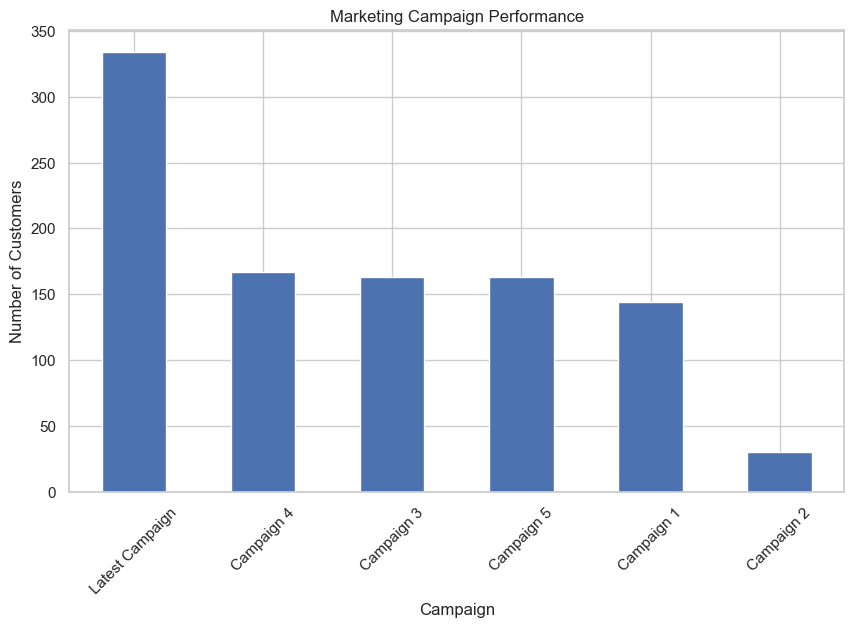

In [52]:
plt.figure(figsize=(10, 6))

campaign_response.plot(kind="bar")

plt.title("Marketing Campaign Performance")
plt.xlabel("Campaign")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.savefig(
    os.path.join(image_folder, "07_campaign_performance.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


### Business Insight

Campaign response differs across campaigns, indicating that some campaigns are more effective than others.

**Recommendation:** Compare the profiles of customers responding to stronger campaigns and use those characteristics to improve future targeting.


## EDA 8 — Income vs Total Spending

**Business Question:** Do higher-income customers tend to spend more?


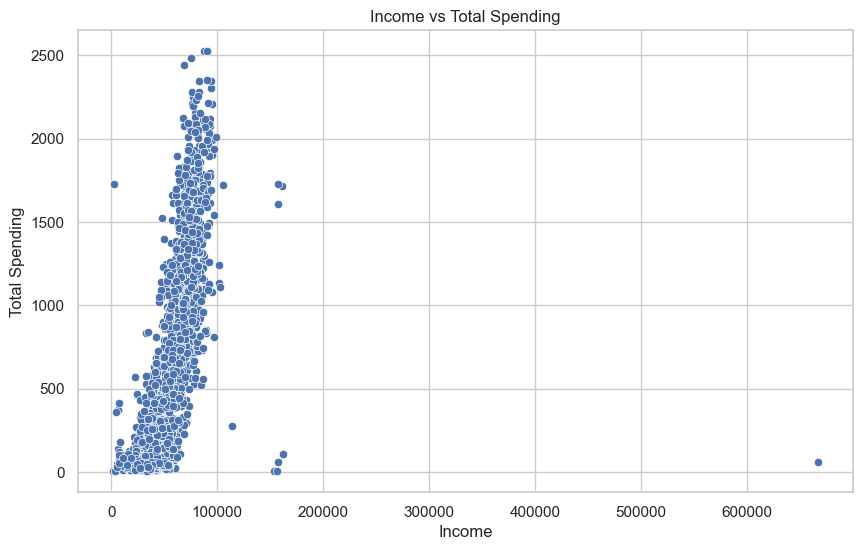

In [53]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Income",
    y="Total_Spending"
)

plt.title("Income vs Total Spending")
plt.xlabel("Income")
plt.ylabel("Total Spending")
plt.savefig(
    os.path.join(image_folder, "08_income_vs_spending.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


### Business Insight

Higher-income customers generally show greater spending potential, although income does not fully explain individual spending behavior.

**Recommendation:** Use income together with spending and purchase behavior when identifying high-value customers.


## EDA 9 — Age vs Total Spending

**Business Question:** Does age appear to be related to customer spending?


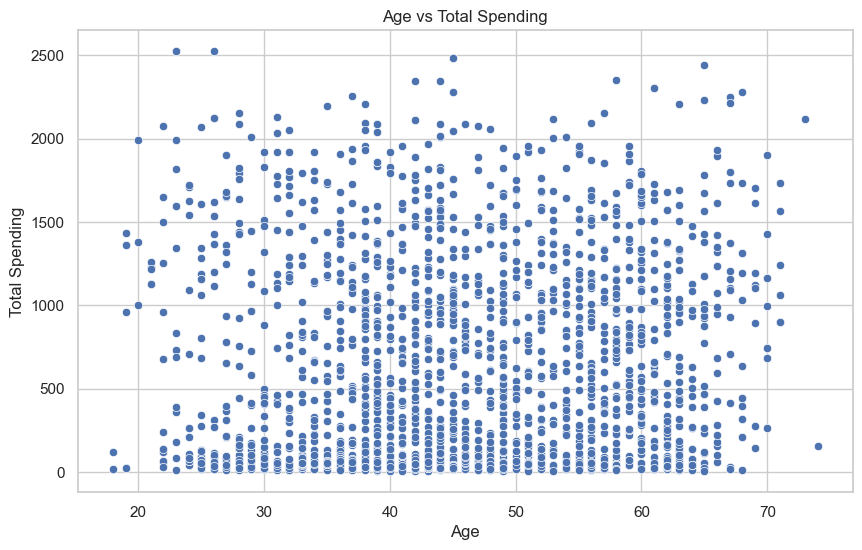

In [54]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df[df["Age_Valid"]],
    x="Age",
    y="Total_Spending"
)

plt.title("Age vs Total Spending")
plt.xlabel("Age")
plt.ylabel("Total Spending")
plt.savefig(
    os.path.join(image_folder, "09_age_vs_spending.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


### Business Insight

Spending varies across age groups, with stronger spending visible among middle-aged and older customers.

**Recommendation:** Use age as a supporting factor for personalization rather than treating it as the only driver of customer value.


## EDA 10 — Income Outliers

**Business Question:** Are there unusual income values that could affect analysis?


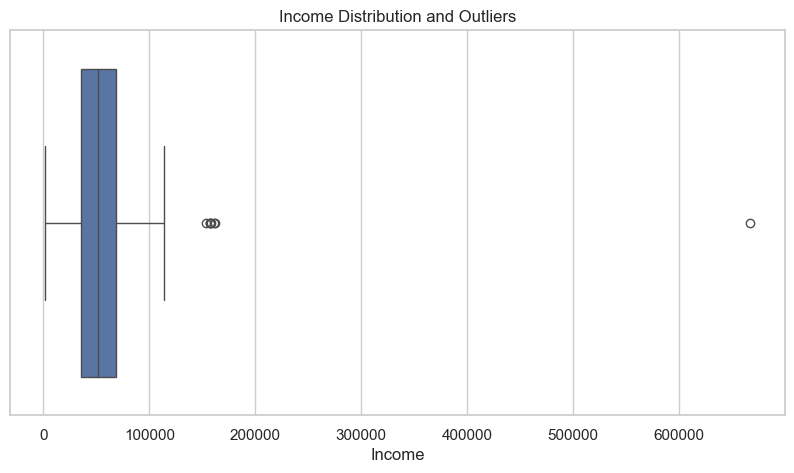

In [55]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=df, x="Income")

plt.title("Income Distribution and Outliers")
plt.xlabel("Income")
plt.savefig(
    os.path.join(image_folder, "10_income_outliers.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


### Business Insight

A small number of customers have unusually high income values. These can influence averages and should be checked before using mean income as a key business metric.


## EDA 11 — Correlation Analysis

**Business Question:** Which numerical variables are related to customer spending and purchasing behavior?


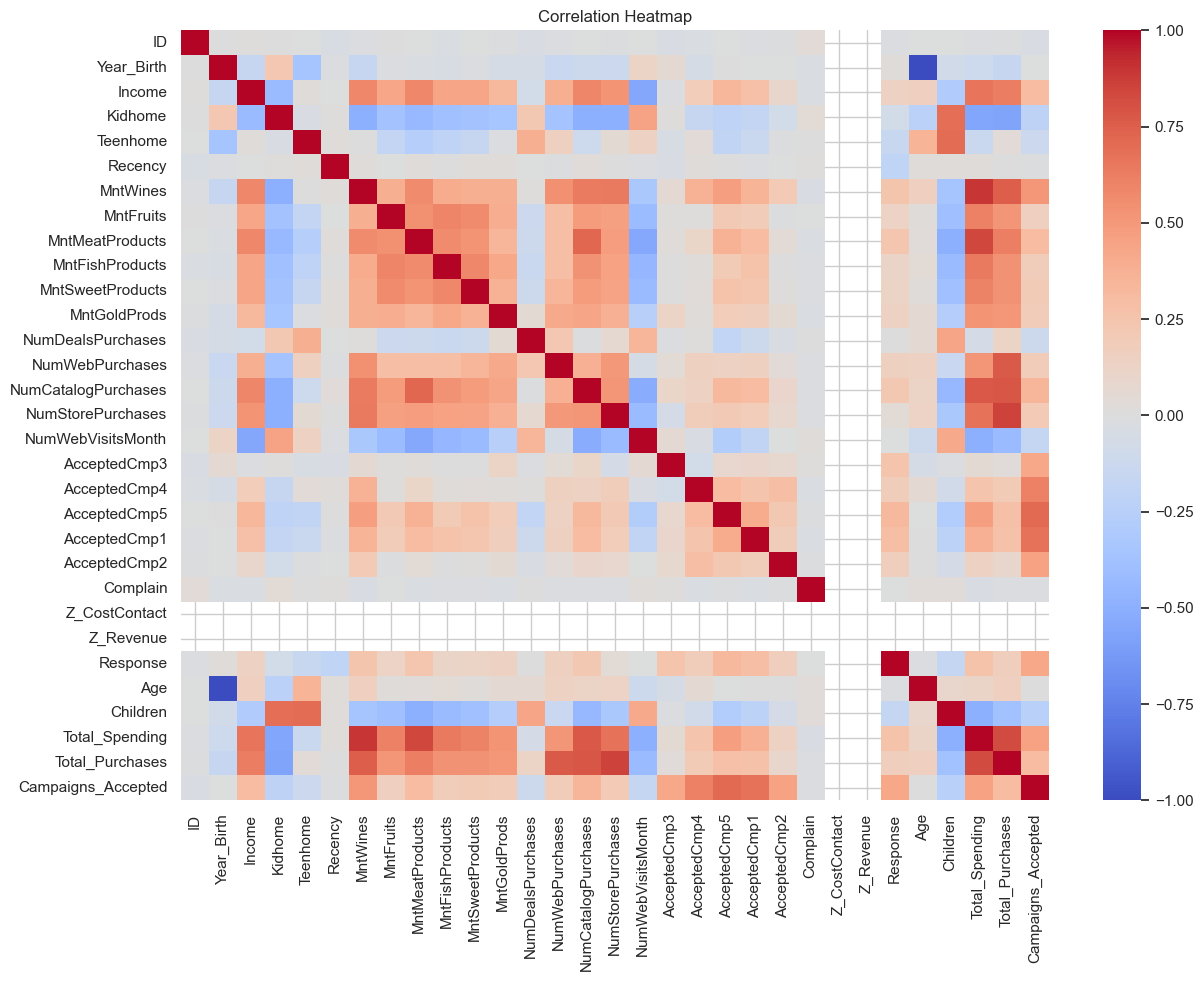

In [56]:
corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")
plt.savefig(
    os.path.join(image_folder, "11_correlation_heatmap.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


### Business Insight

Correlation helps identify variables that move together, but it does not prove that one variable causes another. The strongest relationships with spending and purchasing behavior should be considered when building customer profiles.


## EDA 12 — Top 10 High-Value Customers

**Business Question:** Which customers have the highest total spending?


In [32]:
top_customers = (
    df[
        ["ID", "Income", "Age", "Total_Spending", "Total_Purchases"]
    ]
    .sort_values("Total_Spending", ascending=False)
    .head(10)
)

top_customers


,ID,Income,Age,Total_Spending,Total_Purchases
1572,5350,90638.0,23,2525,17
1179,5735,90638.0,23,2525,17
1492,1763,87679.0,26,2524,28
987,4580,75759.0,45,2486,25
1052,4475,69098.0,65,2440,24
1601,5453,90226.0,58,2352,23
1458,10133,93790.0,44,2349,25
1288,9010,83151.0,42,2346,22
943,5386,94384.0,61,2302,18
1301,6024,94384.0,61,2302,18


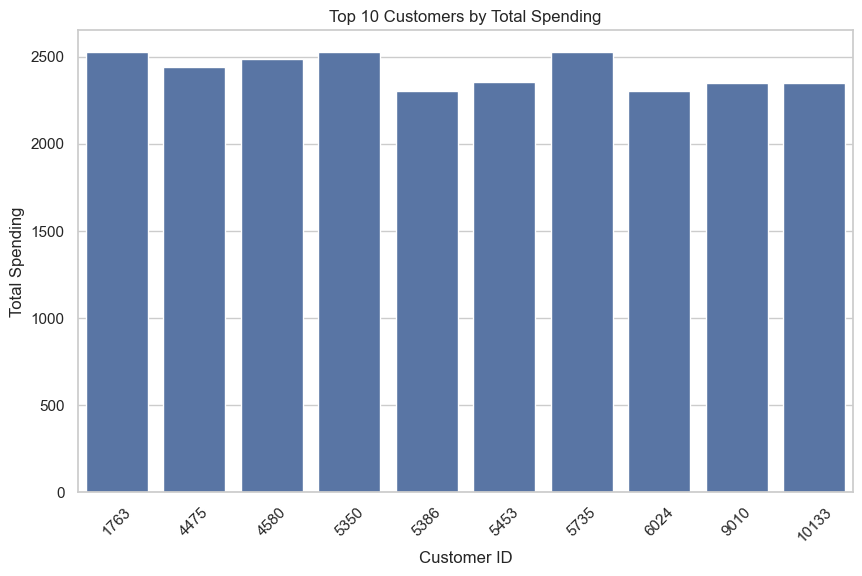

In [57]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_customers,
    x="ID",
    y="Total_Spending"
)

plt.title("Top 10 Customers by Total Spending")
plt.xlabel("Customer ID")
plt.ylabel("Total Spending")
plt.xticks(rotation=45)

plt.savefig(
    os.path.join(image_folder, "12_top_10_customers.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

### Business Insight

The Top 10 customers represent the highest-spending customers in the dataset.

**Recommendation:** These customers are candidates for retention-focused actions such as loyalty rewards, personalized offers, and premium product recommendations.


## EDA 13 — Average Spending by Education

**Business Question:** Does average customer spending differ across education groups?


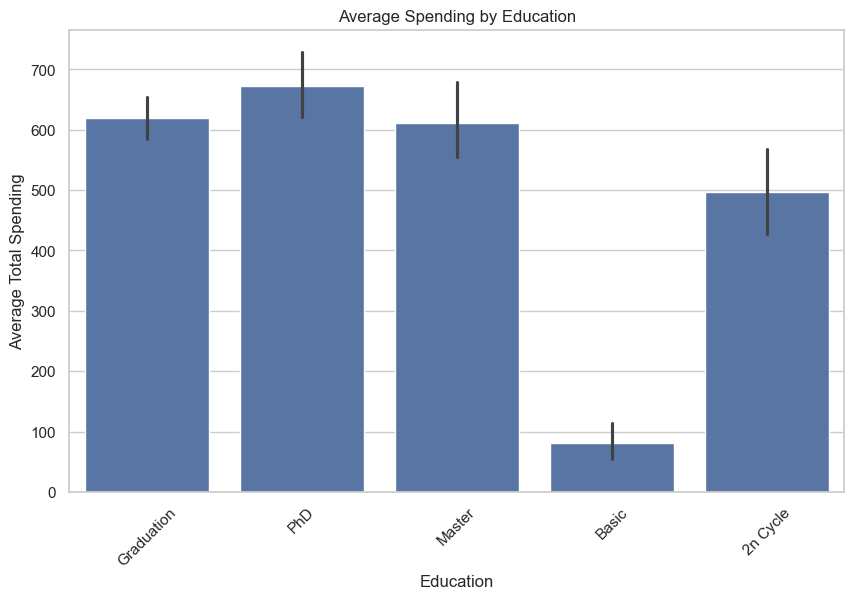

In [58]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x="Education",
    y="Total_Spending"
)

plt.title("Average Spending by Education")
plt.xlabel("Education")
plt.ylabel("Average Total Spending")
plt.xticks(rotation=45)
plt.savefig(
    os.path.join(image_folder, "13_average_spending_education.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


### Business Insight

Average spending differs across education groups.

**Recommendation:** Education can be used as a supporting segmentation variable, but it should be combined with income, spending, and purchase behavior before making targeting decisions.


# 7. Customer Segmentation

## Segmentation Approach

Customers are segmented using data-driven percentile thresholds based on `Total_Spending`.

- **Low Value:** Up to the 25th percentile
- **Medium Value:** 25th to 50th percentile
- **High Value:** 50th to 75th percentile
- **VIP:** Above the 75th percentile

This is a rule-based business segmentation approach using Python/Pandas; no machine learning or clustering is used.


In [34]:
spending_stats = df["Total_Spending"].describe()

q25 = spending_stats["25%"]
q50 = spending_stats["50%"]
q75 = spending_stats["75%"]

print("25th percentile:", q25)
print("50th percentile:", q50)
print("75th percentile:", q75)


25th percentile: 68.75
50th percentile: 396.0
75th percentile: 1045.5


In [35]:
df["Customer_Segment"] = pd.cut(
    df["Total_Spending"],
    bins=[-np.inf, q25, q50, q75, np.inf],
    labels=["Low Value", "Medium Value", "High Value", "VIP"],
    include_lowest=True
)

df["Customer_Segment"].value_counts().sort_index()


Customer_Segment
Low Value       560
Medium Value    561
High Value      559
VIP             560
Name: count, dtype: int64

In [36]:
segment_percentage = (
    df["Customer_Segment"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

segment_percentage


Customer_Segment
Low Value       25.00
Medium Value    25.04
High Value      24.96
VIP             25.00
Name: proportion, dtype: float64

## Segment Profile

We compare income, spending, and purchase activity across the segments to understand their business value.


In [37]:
segment_analysis = (
    df.groupby("Customer_Segment", observed=True)[
        ["Income", "Total_Spending", "Total_Purchases"]
    ]
    .mean()
    .round(2)
)

segment_analysis


,Income,Total_Spending,Total_Purchases
Customer_Segment,,,
Low Value,32351.39,39.26,4.31
Medium Value,40911.36,184.57,8.27
High Value,60419.12,709.82,17.59
VIP,75238.19,1490.48,19.99


In [38]:
segment_summary = (
    df.groupby("Customer_Segment", observed=True)
    .agg(
        Customers=("ID", "count"),
        Customer_Share=("ID", lambda x: round(len(x) / len(df) * 100, 2)),
        Avg_Income=("Income", "mean"),
        Avg_Spending=("Total_Spending", "mean"),
        Avg_Purchases=("Total_Purchases", "mean")
    )
    .round(2)
)

segment_summary


,Customers,Customer_Share,Avg_Income,Avg_Spending,Avg_Purchases
Customer_Segment,,,,,
Low Value,560,25.00,32351.39,39.26,4.31
Medium Value,561,25.04,40911.36,184.57,8.27
High Value,559,24.96,60419.12,709.82,17.59
VIP,560,25.00,75238.19,1490.48,19.99


# 8. Final Business Insights & Recommendations

## Key Finding 1 — Customer Value

The 2,240 customers were divided into four spending-based segments, with each segment representing approximately 25% of the customer base.

- **Low Value:** 560 customers (25.0%), average spending = 39.26
- **Medium Value:** 561 customers (25.04%), average spending = 184.57
- **High Value:** 559 customers (24.96%), average spending = 709.82
- **VIP:** 560 customers (25.0%), average spending = 1,490.48

VIP customers spend approximately **38× more than Low Value customers** and make about **4.6× more purchases** on average.

**Recommendation:** Prioritize VIP retention through loyalty rewards, personalized offers, and premium product recommendations.

---

## Key Finding 2 — Growth Opportunity

High Value customers have an average spending of **709.82** and make approximately **17.59 purchases**, compared with **19.99 purchases** for VIP customers.

High Value customers also have an average income of **60,419**, compared with **75,238** for VIP customers.

**Recommendation:** Use cross-selling, product bundles, and personalized offers to increase engagement among High Value customers and move suitable customers toward VIP-level value.

---

## Key Finding 3 — Re-engagement Opportunity

Low Value customers represent **25% of the customer base**, but their average spending is only **39.26**, compared with **1,490.48** for VIP customers.

Their average purchase activity is also only **4.31 purchases**, compared with **19.99 purchases** for VIP customers.

**Recommendation:** Use targeted discounts, entry-level bundles, and re-engagement campaigns to increase purchase frequency among Low Value customers.

---

## Key Finding 4 — Product Opportunity

Total product spending is **1,356,988**.

- **Wine:** 680,816 (**50.17%**)
- **Meat:** 373,968 (**27.56%**)
- Gold: 98,609 (7.27%)
- Fish: 84,057 (6.19%)
- Sweets: 60,621 (4.47%)
- Fruits: 58,917 (4.34%)

Wine and Meat together contribute **77.73% of total product spending**.

**Recommendation:** Protect the performance of Wine and Meat while using cross-selling and bundle offers to increase spending in lower-performing categories.

---

## Key Finding 5 — Purchase Channel Opportunity

The dataset contains **28,083 recorded purchases** across Web, Catalog, and Store channels.

- **Store:** 12,970 (**46.18%**)
- **Web:** 9,150 (**32.58%**)
- **Catalog:** 5,963 (**21.23%**)

Store purchases account for almost **half of all recorded purchases**.

**Recommendation:** Continue strengthening the Store channel while using targeted digital and catalog promotions to improve the weaker channels.

---

## Key Finding 6 — Campaign Opportunity

The latest campaign (`Response`) received responses from **334 customers**, representing **14.91%** of the customer base.

Among the previous campaigns:

- Campaign 4: **167 responses (7.46%)**
- Campaign 3: **163 responses (7.28%)**
- Campaign 5: **163 responses (7.28%)**
- Campaign 1: **144 responses (6.43%)**
- Campaign 2: **30 responses (1.34%)**

The latest campaign response rate was approximately **2× the response rate of Campaign 4**, the strongest previous campaign.

**Recommendation:** Analyze the characteristics of customers responding to the latest and strongest campaigns and use those profiles for future targeted marketing.

# 9. Potential Business Impact

The analysis identified clear opportunities to improve customer targeting and marketing performance.

- **560 VIP customers (25% of customers)** have average spending of **1,490.48**. Retaining this group can help protect high-value customer revenue.
- **560 Low Value customers (25% of customers)** spend only **39.26** on average. Targeted discounts and bundles could help increase their purchase activity.
- **Wine and Meat products contribute 77.73% of total product spending**, so these categories can be used for cross-selling and bundle offers.
- **Store purchases account for 46.18% of all recorded purchases**, making the store the strongest channel. The company can focus on improving Web and Catalog purchases.
- The latest campaign received responses from **334 customers (14.91%)**, showing stronger response than the previous campaigns.

These numbers show where the company should focus its marketing efforts. However, the project does not measure actual revenue growth because no real marketing experiment was conducted. Therefore, any future improvement in sales, retention, or conversion should be measured after implementing these recommendations.

# 10. Conclusion

This project analyzed **2,240 customers** using Python to understand their demographics, spending habits, purchase channels, and response to marketing campaigns.

Based on spending behavior, customers were divided into **Low Value, Medium Value, High Value, and VIP** segments. The analysis showed clear differences in spending and purchase activity across these groups.

The findings can help the business focus on **retaining VIP customers, improving low-value customer engagement, promoting high-performing products, and making marketing campaigns more targeted**.

Overall, the project shows how customer data can be turned into simple and useful business decisions.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

# Checking new columns

In [39]:
df.columns.tolist()

['ID',
 'Year_Birth',
 'Education',
 'Marital_Status',
 'Income',
 'Kidhome',
 'Teenhome',
 'Dt_Customer',
 'Recency',
 'MntWines',
 'MntFruits',
 'MntMeatProducts',
 'MntFishProducts',
 'MntSweetProducts',
 'MntGoldProds',
 'NumDealsPurchases',
 'NumWebPurchases',
 'NumCatalogPurchases',
 'NumStorePurchases',
 'NumWebVisitsMonth',
 'AcceptedCmp3',
 'AcceptedCmp4',
 'AcceptedCmp5',
 'AcceptedCmp1',
 'AcceptedCmp2',
 'Complain',
 'Z_CostContact',
 'Z_Revenue',
 'Response',
 'Age',
 'Age_Valid',
 'Children',
 'Total_Spending',
 'Total_Purchases',
 'Campaigns_Accepted',
 'Customer_Segment']

# Downloading new file

In [41]:
df.to_csv(r"C:\Users\mahen\Downloads\marketing_campaign_updated.csv",index = False)